### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
mu : 0.5
x0 : 0.01
x_t0 : 0
T : 15
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 10000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularizer : reg_derivative
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2024-12-22 00:56:42.852044: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-22 00:56:42.861579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734825402.872835   47022 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734825402.876011   47022 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-22 00:56:42.888163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Model: "PhysicsInformedNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***


### Train Physics-Informed Neural Network

In [3]:
training_log = PINN.train()

Training started...
    0/10000 | loss_P: 1.00e+00 | loss_IC: 1.01e-04
 1000/10000 | loss_P: 2.22e-01 | loss_IC: 6.80e-03
 2000/10000 | loss_P: 1.06e-01 | loss_IC: 2.88e-03
 3000/10000 | loss_P: 8.36e-02 | loss_IC: 2.19e-03
 4000/10000 | loss_P: 5.15e-02 | loss_IC: 9.28e-04
 5000/10000 | loss_P: 1.09e-03 | loss_IC: 9.10e-05
 6000/10000 | loss_P: 3.43e-05 | loss_IC: 2.53e-06
 7000/10000 | loss_P: 9.06e-06 | loss_IC: 9.23e-07
 8000/10000 | loss_P: 5.79e-06 | loss_IC: 3.12e-07
 9000/10000 | loss_P: 1.71e-05 | loss_IC: 3.22e-06
*** logs saved ***
Training finished!


# Plot Section

In [4]:
from model.plots import learning_curves, van_der_pol_dynamics, loss_over_tcoll, plot_regularization, results_heatmap, regularization_over_domain

### Learning Curves

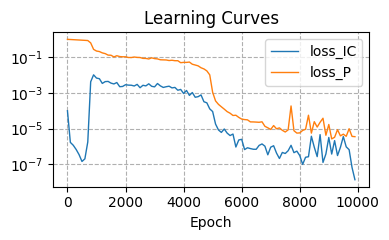

In [5]:
learning_curves(training_log)

### Pendulum Dynamics

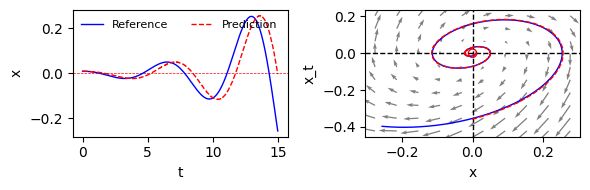

In [6]:
van_der_pol_dynamics(PINN)

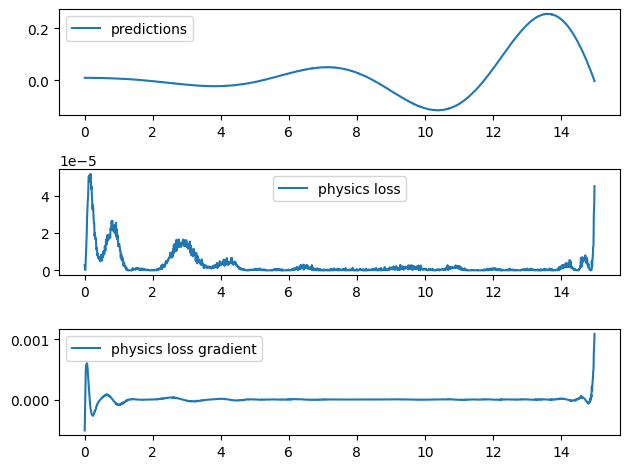

In [7]:
loss_over_tcoll(PINN)

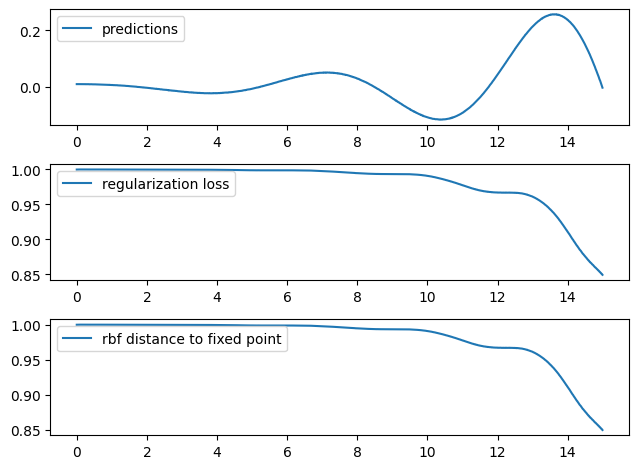

In [8]:
plot_regularization(PINN)

### Regularization landscape

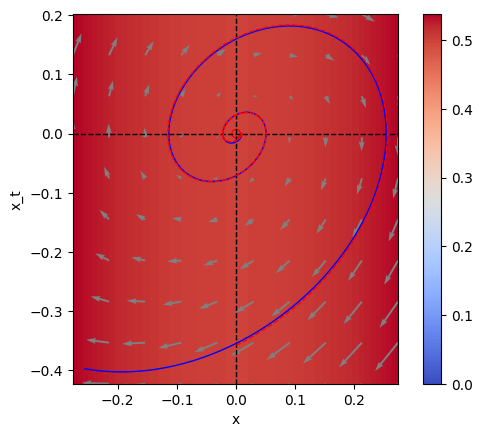

In [9]:
regularization_over_domain(PINN=PINN)

### Training animation

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, ax = plt.subplots()

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, ax


def animate(i, *fargs):
    # get passed arguments
    ax = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    ax.clear()
    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))

    ############################
    # Prediciton plot
    ############################

    # stable/unstable fixed points
    line_props = {'ls': '--', 'lw': 0.5}
    ax.axhline(0, c='green', **line_props)
    ax.axhline(np.pi, c='red', **line_props)
    ax.axhline(-np.pi, c='red', **line_props)

    # Reference data and PINN prediction
    t_line, theta_true, omega_true = PINN.data.reference()
    theta_pred = PINN(t_line)
    
    ##############################
    ### Regularization coefficient
    ##############################
    epoch = flag
    coeff = config["reg_coeff"]
    if config["reg_decay"] == "linear":
        coeff = config["reg_coeff"] * (1 - epoch / config["reg_epochs"])
    
    ax.plot([], [], c='black', lw=1, label=f'regularization coeff {coeff}')
           
    #############################
    ### Updated plot comes here
    #############################

    # make plot
    ax.plot(t_line, theta_true, c='blue', lw=1, label='Reference')
    ax.plot(t_line, theta_pred, c='red', lw=1, ls='--', label='Prediction')

    # Axis appearance
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$\theta$')
    ax.legend(frameon=False, loc=1, ncol=2, fontsize=8)
    ax.set_ylim([-3.5, 3.5])
    


    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [11]:
import pandas as pd
import numpy as np
from model.plots import results_linear_decay
results = pd.read_csv("results_linear_decay.csv")

results_linear_decay(results)

FileNotFoundError: [Errno 2] No such file or directory: 'results_linear_decay.csv'